In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("/Users/bhargavram/Downloads/Sample - Superstore.csv", encoding='latin1')

# Check missing values
print(df.isnull().sum())

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year and Month column
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

# Check duplicates
df.drop_duplicates(inplace=True)

df.head()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,November
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,November
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,June
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,October
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,October


In [4]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Profit Margin:", profit_margin)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Profit Margin: 12.467217240315605


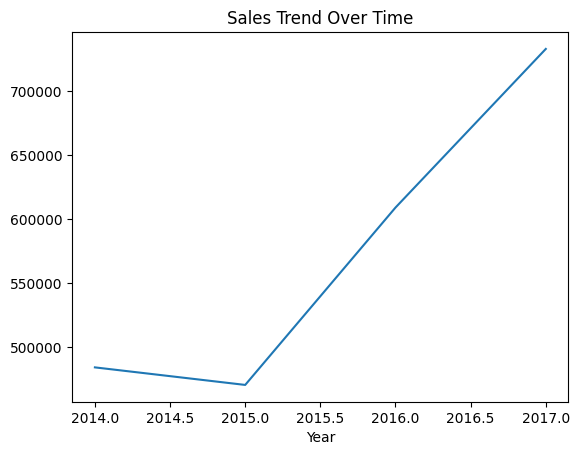

In [5]:
import matplotlib.pyplot as plt

df.groupby('Year')['Sales'].sum().plot(kind='line')
plt.title("Sales Trend Over Time")
plt.show()

In [6]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


/var/folders/g1/9y3t3gsx385227f74jnc_8z40000gn/T/ipykernel_26445/2002924003.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


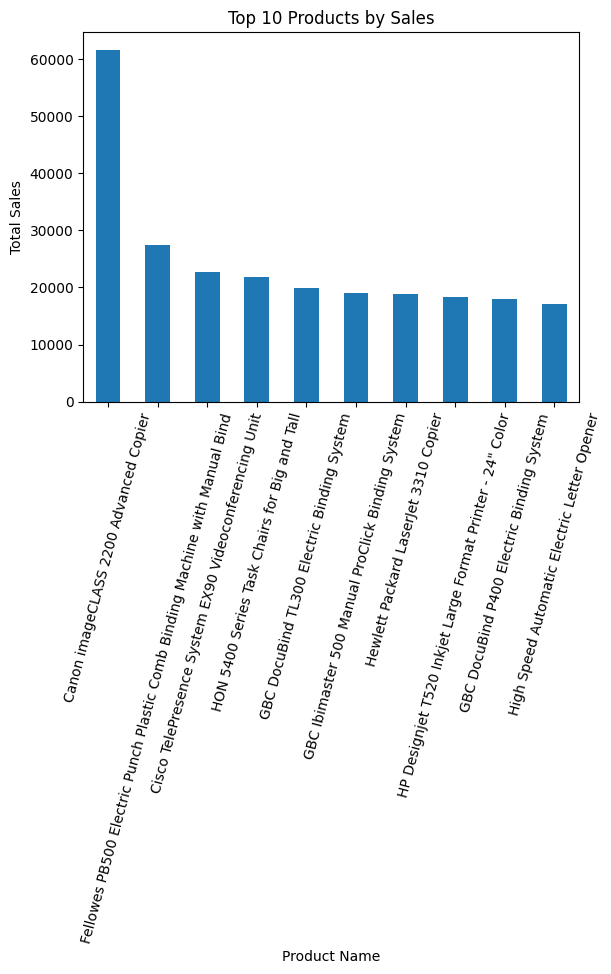

In [7]:
import matplotlib.pyplot as plt

# Plot bar chart
top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [8]:
top_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


/var/folders/g1/9y3t3gsx385227f74jnc_8z40000gn/T/ipykernel_26445/1504542251.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


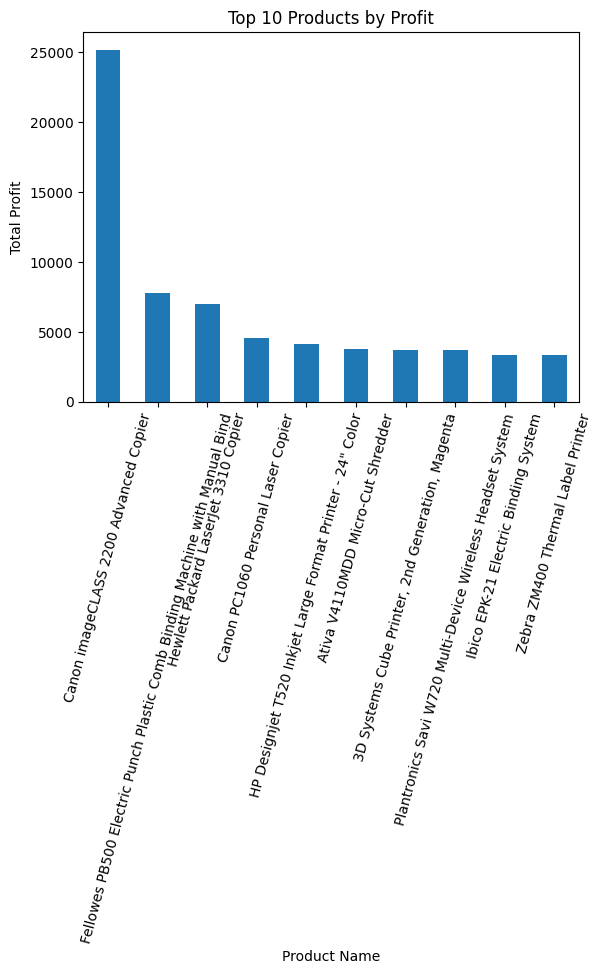

In [9]:
top_profit_products.plot(kind='bar')

plt.title("Top 10 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Total Profit")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [10]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print(top_products)

                                        Product Name      Sales
0              Canon imageCLASS 2200 Advanced Copier  61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
2  Cisco TelePresence System EX90 Videoconferenci...  22638.480
3       HON 5400 Series Task Chairs for Big and Tall  21870.576
4         GBC DocuBind TL300 Electric Binding System  19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
6               Hewlett Packard LaserJet 3310 Copier  18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
8          GBC DocuBind P400 Electric Binding System  17965.068
9        High Speed Automatic Electric Letter Opener  17030.312


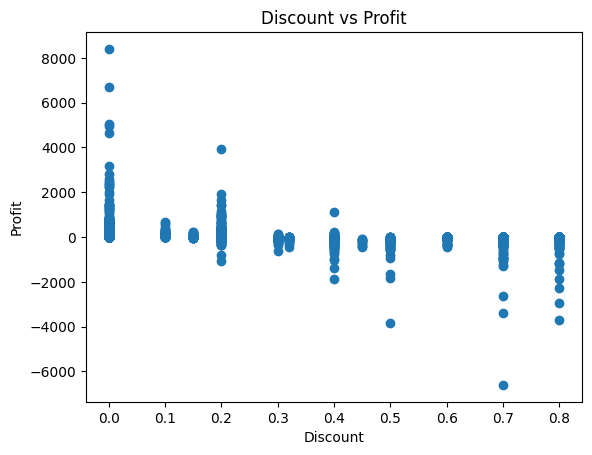

In [11]:
plt.scatter(df['Discount'], df['Profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [12]:
region_data = df.groupby('Region').agg({'Sales':'sum','Profit':'sum'})
region_data['Profit Margin'] = (region_data['Profit']/region_data['Sales'])*100
print(region_data)

               Sales       Profit  Profit Margin
Region                                          
Central  501239.8908   39706.3625       7.921629
East     678781.2400   91522.7800      13.483399
South    391721.9050   46749.4303      11.934342
West     725457.8245  108418.4489      14.944831


In [13]:
cat_data = df.groupby('Category').agg({'Sales':'sum','Profit':'sum'})
cat_data['Profit Margin'] = (cat_data['Profit']/cat_data['Sales'])*100
print(cat_data)

                       Sales       Profit  Profit Margin
Category                                                
Furniture        741999.7953   18451.2728       2.486695
Office Supplies  719047.0320  122490.8008      17.035158
Technology       836154.0330  145454.9481      17.395712


In [14]:
year_sales = df.groupby('Year')['Sales'].sum()
growth = year_sales.pct_change()*100
print(growth)

Year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64


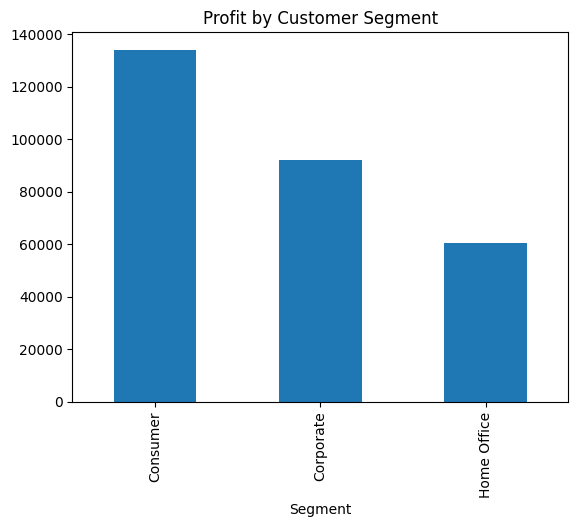

In [15]:
df.groupby('Segment')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Customer Segment")
plt.show()

In [16]:
bottom_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)
print(bottom_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


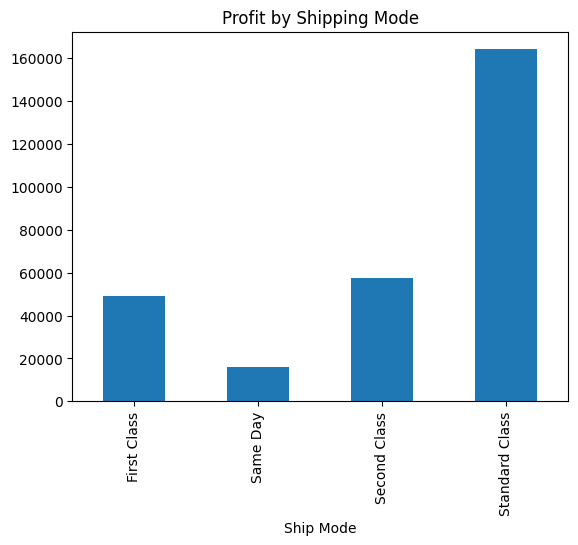

In [17]:
df.groupby('Ship Mode')['Profit'].sum().plot(kind='bar')
plt.title("Profit by Shipping Mode")
plt.show()

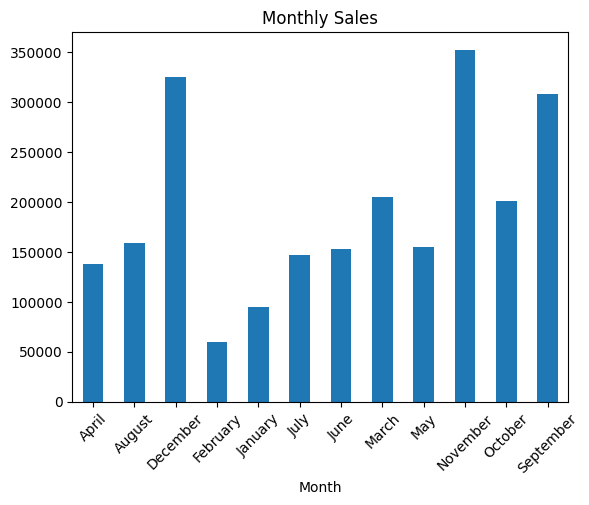

In [18]:
df.groupby('Month')['Sales'].sum().plot(kind='bar')
plt.title("Monthly Sales")
plt.xticks(rotation=45)
plt.show()

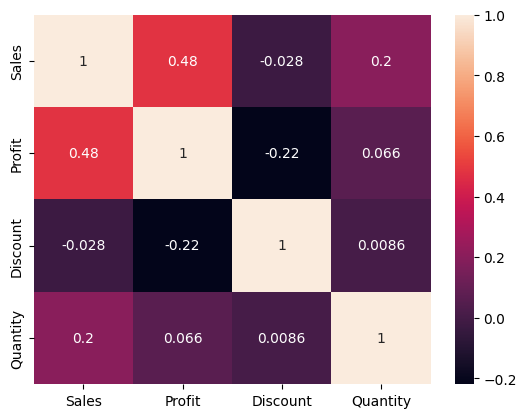

In [20]:
import seaborn as sns

corr = df[['Sales','Profit','Discount','Quantity']].corr()
sns.heatmap(corr, annot=True)
plt.show()